# FraudLens - Exploratory Data Analysis
**Dataset:** IEEE-CIS Fraud Detection (Kaggle)  
**Records:** ~590K transactions · ~3.5% fraud rate  
**Files:** `train_transaction.csv` + `train_identity.csv`

**Sections**
1. Setup & data loading
2. Class imbalance
3. Missing values
4. TransactionAmt distribution
5. Temporal patterns
6. Categorical features (ProductCD, card type, email domain)
7. C features (count)
8. D features (time-delta)
9. M features (match flags)
10. V features (Vesta engineered)
11. Identity features
12. Correlation heatmap
13. Key findings

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

ROOT = Path('..').resolve()
RAW  = ROOT / 'data' / 'raw'

FRAUD_COLOR    = '#e74c3c'
LEGIT_COLOR    = '#2ecc71'
NEUTRAL_COLOR  = '#3498db'

## 1 · Load & merge

In [2]:
txn = pd.read_csv(RAW / 'train_transaction.csv')
idn = pd.read_csv(RAW / 'train_identity.csv')

df = txn.merge(idn, on='TransactionID', how='left')

print(f'Transaction rows : {len(txn):,}')
print(f'Identity rows    : {len(idn):,}  ({len(idn)/len(txn):.1%} have identity)')
print(f'Merged shape     : {df.shape}')
print(f'Memory           : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Transaction rows : 590,540
Identity rows    : 144,233  (24.4% have identity)
Merged shape     : (590540, 434)
Memory           : 2636.1 MB


In [3]:
# Quick column inventory
col_groups = {
    'Meta'        : ['TransactionID', 'isFraud', 'TransactionDT'],
    'Transaction' : ['TransactionAmt', 'ProductCD'],
    'Card'        : [c for c in df.columns if c.startswith('card')],
    'Address'     : ['addr1', 'addr2', 'dist1', 'dist2'],
    'Email'       : ['P_emaildomain', 'R_emaildomain'],
    'C (count)'   : [c for c in df.columns if c.startswith('C') and c[1:].isdigit()],
    'D (timedelta)': [c for c in df.columns if c.startswith('D') and c[1:].isdigit()],
    'M (match)'   : [c for c in df.columns if c.startswith('M') and c[1:].isdigit()],
    'V (Vesta)'   : [c for c in df.columns if c.startswith('V') and c[1:].isdigit()],
    'Identity'    : [c for c in df.columns if c.startswith('id_') or c in ('DeviceType', 'DeviceInfo')],
}

for grp, cols in col_groups.items():
    print(f'{grp:20s}: {len(cols):3d} cols')

Meta                :   3 cols
Transaction         :   2 cols
Card                :   6 cols
Address             :   4 cols
Email               :   2 cols
C (count)           :  14 cols
D (timedelta)       :  15 cols
M (match)           :   9 cols
V (Vesta)           : 339 cols
Identity            :  40 cols


## 2 · Class imbalance

Non-fraud : 569,877  (96.50%)
Fraud     : 20,663  (3.50%)
Imbalance ratio: 27.6:1


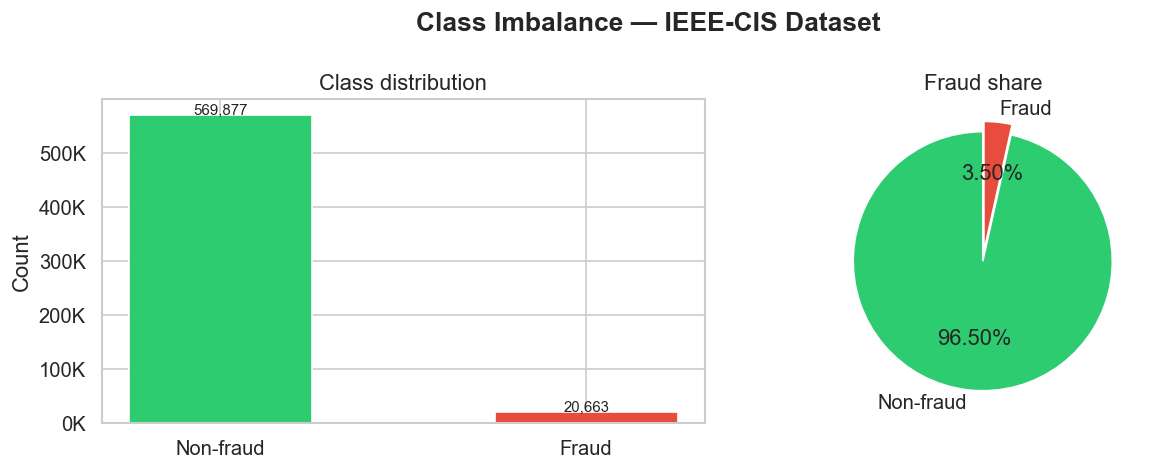

In [ ]:
fraud_counts = df['isFraud'].value_counts()
fraud_rate   = df['isFraud'].mean()

print(f'Non-fraud : {fraud_counts[0]:,}  ({1-fraud_rate:.2%})')
print(f'Fraud     : {fraud_counts[1]:,}  ({fraud_rate:.2%})')
print(f'Imbalance ratio: {fraud_counts[0]/fraud_counts[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar
axes[0].bar(['Non-fraud', 'Fraud'], fraud_counts.values,
            color=[LEGIT_COLOR, FRAUD_COLOR], width=0.5)
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

# Pie
axes[1].pie(
    fraud_counts.values,
    labels=['Non-fraud', 'Fraud'],
    colors=[LEGIT_COLOR, FRAUD_COLOR],
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.08),
)
axes[1].set_title('Fraud share')

plt.suptitle('Class Imbalance - IEEE-CIS Dataset', fontweight='bold')
plt.tight_layout()
plt.show()


Heavy class imbalance (~3.5%). AUC-PR is the primary metric.
Training will use class_weight / scale_pos_weight to compensate.

## 3 · Missing values

In [5]:
miss = df.isnull().mean().sort_values(ascending=False)
miss_pct = (miss * 100).round(1)

print('Columns with >50% missing:')
print(miss_pct[miss_pct > 50].to_string())
print(f'\nTotal columns    : {len(df.columns)}')
print(f'Zero missing     : {(miss == 0).sum()}')
print(f'<10% missing     : {(miss < 0.10).sum()}')
print(f'>50% missing     : {(miss > 0.50).sum()}')
print(f'>90% missing     : {(miss > 0.90).sum()}')

Columns with >50% missing:
id_24            99.2
id_25            99.1
id_07            99.1
id_08            99.1
id_21            99.1
id_26            99.1
id_27            99.1
id_23            99.1
id_22            99.1
dist2            93.6
D7               93.4
id_18            92.4
D13              89.5
D14              89.5
D12              89.0
id_03            88.8
id_04            88.8
D6               87.6
id_33            87.6
id_10            87.3
id_09            87.3
D9               87.3
D8               87.3
id_30            86.9
id_32            86.9
id_34            86.8
id_14            86.4
V142             86.1
V158             86.1
V140             86.1
V162             86.1
V141             86.1
V161             86.1
V157             86.1
V146             86.1
V156             86.1
V155             86.1
V154             86.1
V153             86.1
V149             86.1
V147             86.1
V148             86.1
V163             86.1
V139             86.1
V138 

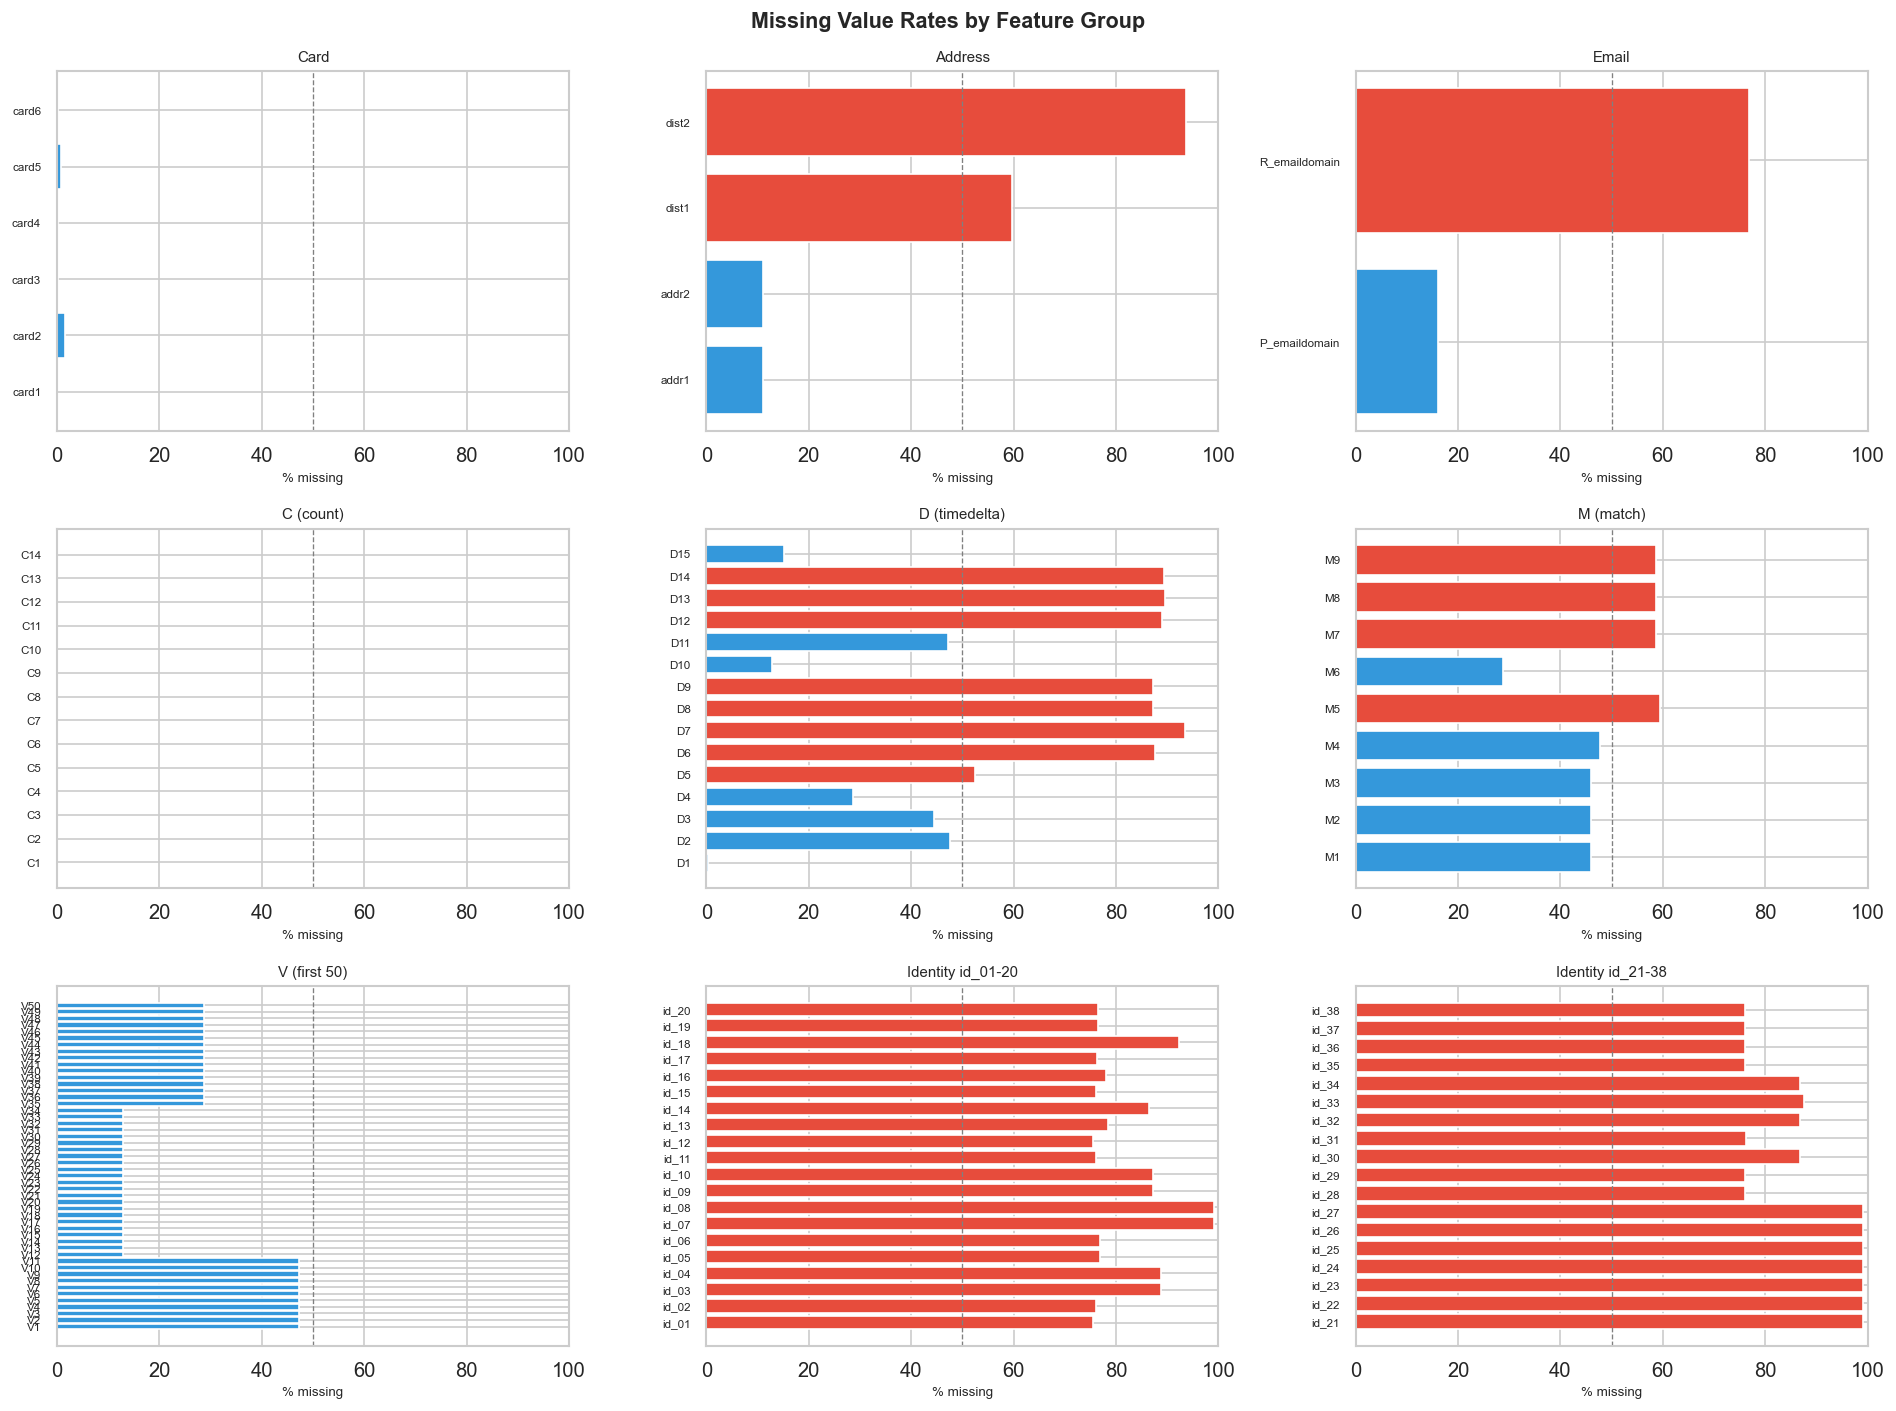

→ D and V features have the most missingness.
  Strategy: median imputation for numeric, sentinel -1 for M-flags.


In [6]:
# Missing rate by column group
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

groups_to_plot = [
    ('Card',          col_groups['Card']),
    ('Address',       col_groups['Address']),
    ('Email',         col_groups['Email']),
    ('C (count)',     col_groups['C (count)']),
    ('D (timedelta)', col_groups['D (timedelta)']),
    ('M (match)',     col_groups['M (match)']),
    ('V (first 50)',  col_groups['V (Vesta)'][:50]),
    ('Identity id_01-20', [c for c in col_groups['Identity'] if 'id_' in c][:20]),
    ('Identity id_21-38', [c for c in col_groups['Identity'] if 'id_' in c][20:]),
]

for ax, (title, cols) in zip(axes, groups_to_plot):
    cols_present = [c for c in cols if c in df.columns]
    grp_miss = df[cols_present].isnull().mean() * 100
    colors = [FRAUD_COLOR if v > 50 else NEUTRAL_COLOR for v in grp_miss.values]
    ax.barh(grp_miss.index, grp_miss.values, color=colors)
    ax.set_title(title, fontsize=9)
    ax.set_xlim(0, 100)
    ax.axvline(50, color='gray', linestyle='--', linewidth=0.8)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_xlabel('% missing', fontsize=8)

plt.suptitle('Missing Value Rates by Feature Group', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('→ D and V features have the most missingness.')
print('  Strategy: median imputation for numeric, sentinel -1 for M-flags.')

## 4 · TransactionAmt distribution

TransactionAmt summary:
              count    mean     std   min    25%   50%    75%       max
Non-fraud  569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
Fraud       20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


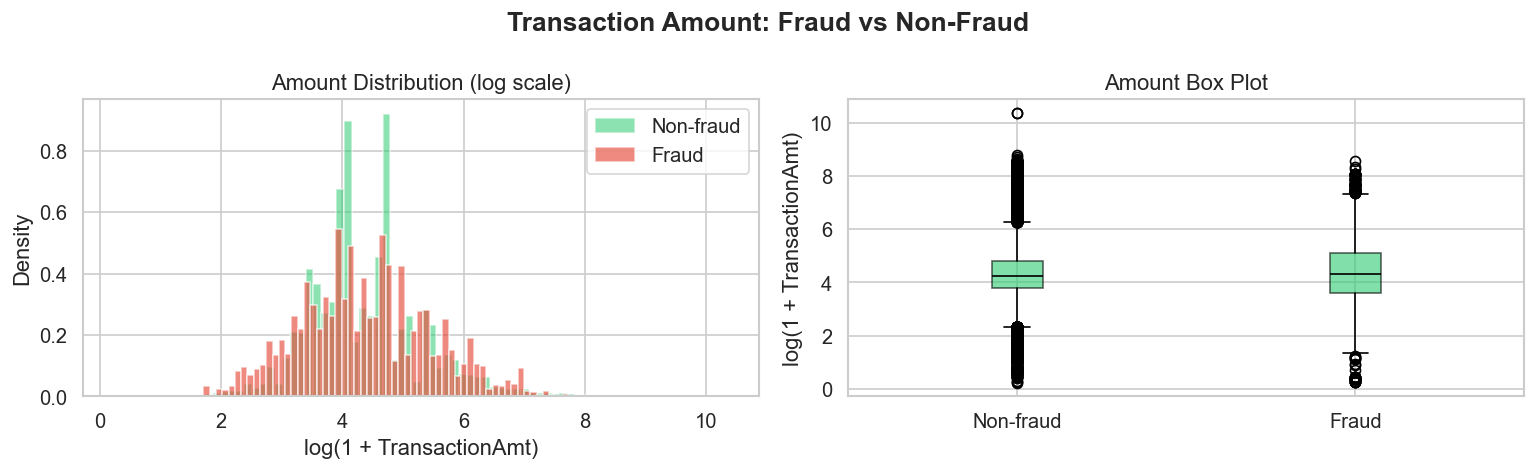


Fraud median  : $75.00
Legit median  : $68.50
Fraud mean    : $149.24
Legit mean    : $134.51


In [7]:
fraud  = df[df['isFraud'] == 1]['TransactionAmt']
legit  = df[df['isFraud'] == 0]['TransactionAmt']

print('TransactionAmt summary:')
summary = df.groupby('isFraud')['TransactionAmt'].describe().round(2)
summary.index = ['Non-fraud', 'Fraud']
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Log-scale KDE
log_fraud = np.log1p(fraud)
log_legit = np.log1p(legit)
axes[0].hist(log_legit, bins=80, alpha=0.55, color=LEGIT_COLOR,
             density=True, label='Non-fraud')
axes[0].hist(log_fraud, bins=80, alpha=0.65, color=FRAUD_COLOR,
             density=True, label='Fraud')
axes[0].set_xlabel('log(1 + TransactionAmt)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution (log scale)')
axes[0].legend()

# Box plots
axes[1].boxplot(
    [np.log1p(legit), np.log1p(fraud)],
    labels=['Non-fraud', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor=LEGIT_COLOR, alpha=0.6),
    medianprops=dict(color='black'),
)
axes[1].set_ylabel('log(1 + TransactionAmt)')
axes[1].set_title('Amount Box Plot')

plt.suptitle('Transaction Amount: Fraud vs Non-Fraud', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nFraud median  : ${fraud.median():,.2f}')
print(f'Legit median  : ${legit.median():,.2f}')
print(f'Fraud mean    : ${fraud.mean():,.2f}')
print(f'Legit mean    : ${legit.mean():,.2f}')

## 5 · Temporal patterns

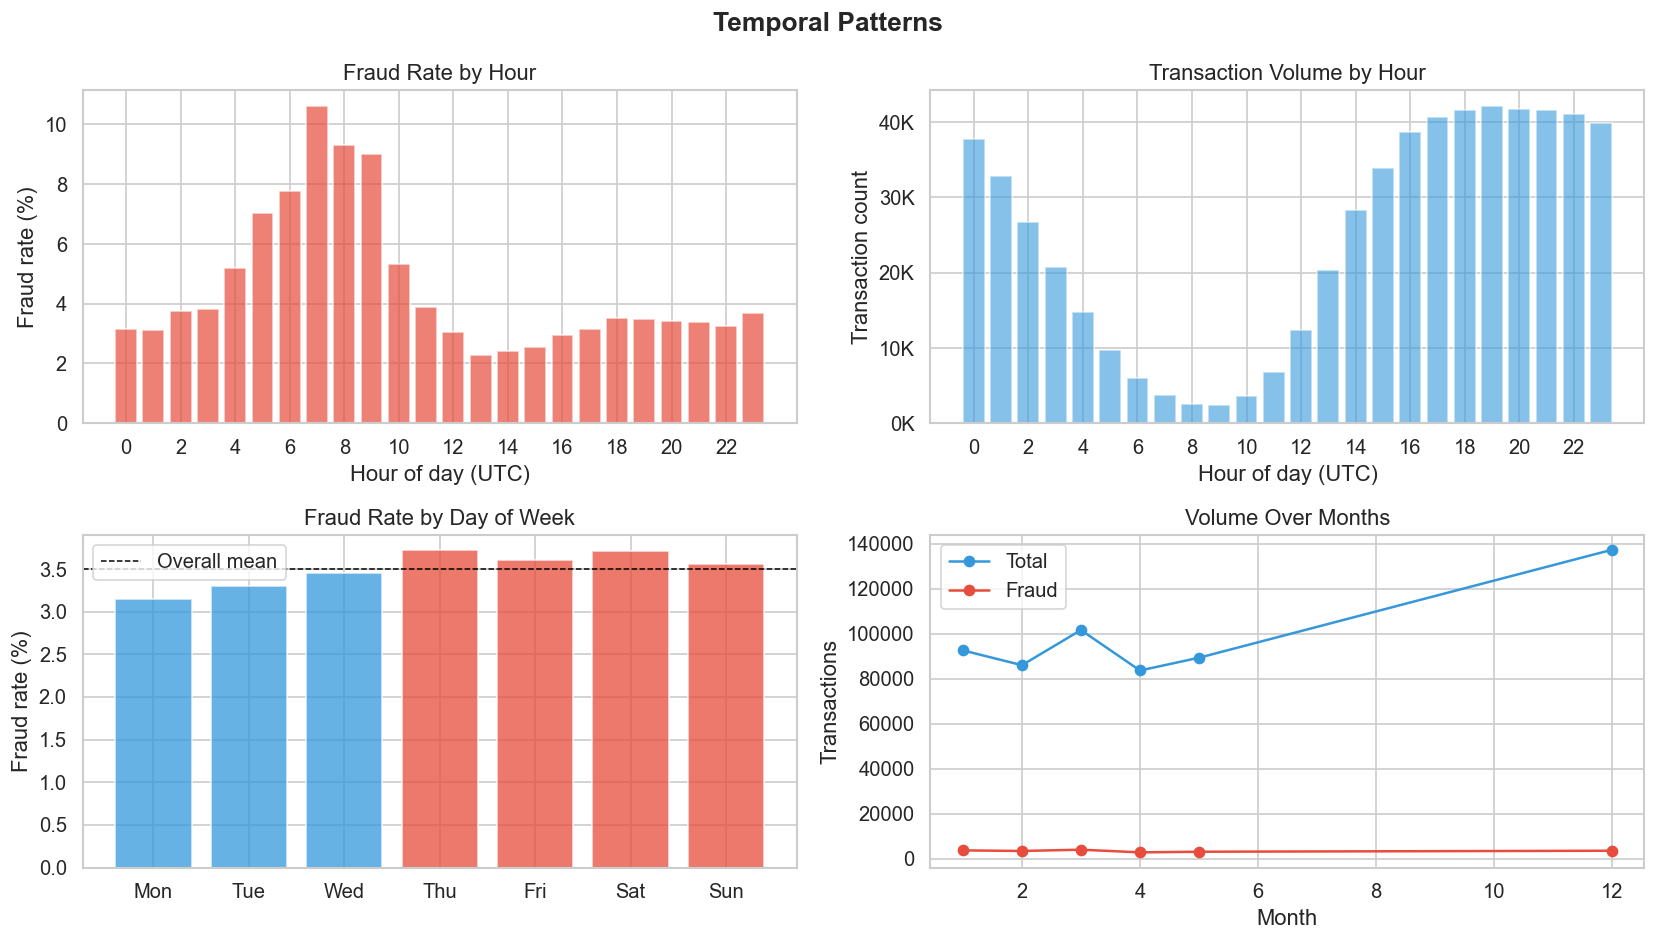

In [8]:
# TransactionDT is seconds since 2017-11-30
DT_ORIGIN = pd.Timestamp('2017-11-30')
dt = DT_ORIGIN + pd.to_timedelta(df['TransactionDT'], unit='s')

df['_hour']        = dt.dt.hour
df['_day_of_week'] = dt.dt.dayofweek
df['_month']       = dt.dt.month

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Fraud rate by hour
hour_rate = df.groupby('_hour')['isFraud'].mean()
hour_vol  = df.groupby('_hour')['isFraud'].count()
ax = axes[0, 0]
bars = ax.bar(hour_rate.index, hour_rate.values * 100, color=FRAUD_COLOR, alpha=0.7)
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud Rate by Hour')
ax.set_xticks(range(0, 24, 2))

# Volume by hour
ax2 = axes[0, 1]
ax2.bar(hour_vol.index, hour_vol.values, color=NEUTRAL_COLOR, alpha=0.6,
        label='Non-fraud')
ax2.set_xlabel('Hour of day (UTC)')
ax2.set_ylabel('Transaction count')
ax2.set_title('Transaction Volume by Hour')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax2.set_xticks(range(0, 24, 2))

# Fraud rate by day of week
dow_rate = df.groupby('_day_of_week')['isFraud'].mean()
axes[1, 0].bar(
    range(7), dow_rate.values * 100,
    color=[FRAUD_COLOR if r > dow_rate.mean() else NEUTRAL_COLOR for r in dow_rate.values],
    alpha=0.75
)
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(day_names)
axes[1, 0].set_ylabel('Fraud rate (%)')
axes[1, 0].set_title('Fraud Rate by Day of Week')
axes[1, 0].axhline(dow_rate.mean() * 100, color='black', linestyle='--',
                   linewidth=0.9, label='Overall mean')
axes[1, 0].legend()

# Fraud volume over time (monthly)
month_stats = df.groupby('_month').agg(
    total=('isFraud', 'count'),
    fraud=('isFraud', 'sum')
)
axes[1, 1].plot(month_stats.index, month_stats['total'], marker='o',
                color=NEUTRAL_COLOR, label='Total')
axes[1, 1].plot(month_stats.index, month_stats['fraud'], marker='o',
                color=FRAUD_COLOR, label='Fraud')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Transactions')
axes[1, 1].set_title('Volume Over Months')
axes[1, 1].legend()

plt.suptitle('Temporal Patterns', fontweight='bold')
plt.tight_layout()
plt.show()

# Clean up temp columns
df.drop(columns=['_hour', '_day_of_week', '_month'], inplace=True)

## 6 · Categorical features

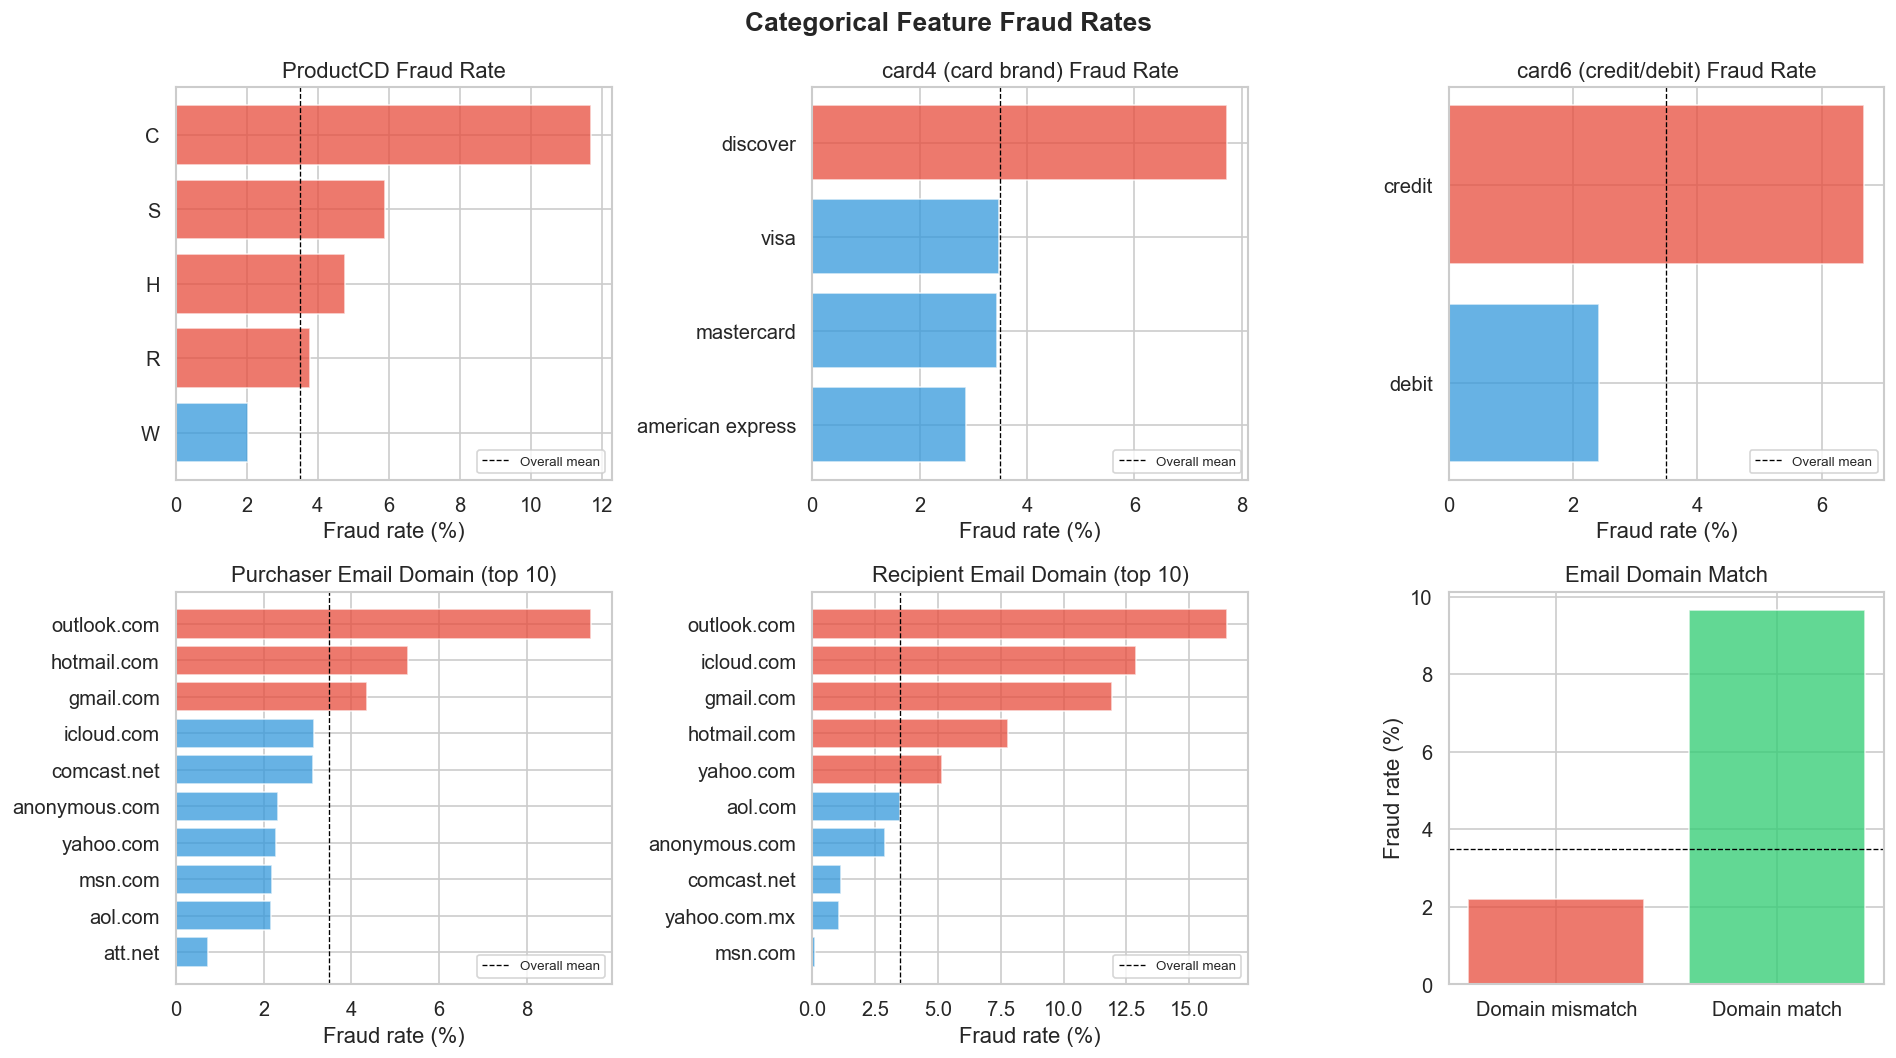

In [9]:
def fraud_rate_bar(ax, col, title, top_n=10, min_count=100):
    """Bar chart of fraud rate per category value, filtered to top_n by volume."""
    agg = (
        df.groupby(col)['isFraud']
        .agg(['mean', 'count'])
        .query('count >= @min_count')
        .sort_values('count', ascending=False)
        .head(top_n)
        .sort_values('mean', ascending=True)
    )
    colors = [FRAUD_COLOR if v > df['isFraud'].mean() else NEUTRAL_COLOR
              for v in agg['mean'].values]
    ax.barh(agg.index.astype(str), agg['mean'] * 100, color=colors, alpha=0.75)
    ax.axvline(df['isFraud'].mean() * 100, color='black', linestyle='--',
               linewidth=0.8, label='Overall mean')
    ax.set_xlabel('Fraud rate (%)')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

fraud_rate_bar(axes[0, 0], 'ProductCD',      'ProductCD Fraud Rate')
fraud_rate_bar(axes[0, 1], 'card4',          'card4 (card brand) Fraud Rate')
fraud_rate_bar(axes[0, 2], 'card6',          'card6 (credit/debit) Fraud Rate')
fraud_rate_bar(axes[1, 0], 'P_emaildomain',  'Purchaser Email Domain (top 10)')
fraud_rate_bar(axes[1, 1], 'R_emaildomain',  'Recipient Email Domain (top 10)')

# Email domain match
email_match = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)
match_rate  = df.groupby(email_match)['isFraud'].mean() * 100
axes[1, 2].bar(
    ['Domain mismatch', 'Domain match'],
    match_rate.values,
    color=[FRAUD_COLOR, LEGIT_COLOR],
    alpha=0.75
)
axes[1, 2].axhline(df['isFraud'].mean() * 100, color='black',
                    linestyle='--', linewidth=0.8)
axes[1, 2].set_ylabel('Fraud rate (%)')
axes[1, 2].set_title('Email Domain Match')

plt.suptitle('Categorical Feature Fraud Rates', fontweight='bold')
plt.tight_layout()
plt.show()

## 7 · C features (count features)

C feature summary (fraud vs non-fraud medians):
     Non-fraud  Fraud
C1         1.0    2.0
C2         1.0    2.0
C3         0.0    0.0
C4         0.0    1.0
C5         0.0    0.0
C6         1.0    1.0
C7         0.0    0.0
C8         0.0    1.0
C9         1.0    0.0
C10        0.0    1.0
C11        1.0    2.0
C12        0.0    0.0
C13        3.0    1.0
C14        1.0    1.0


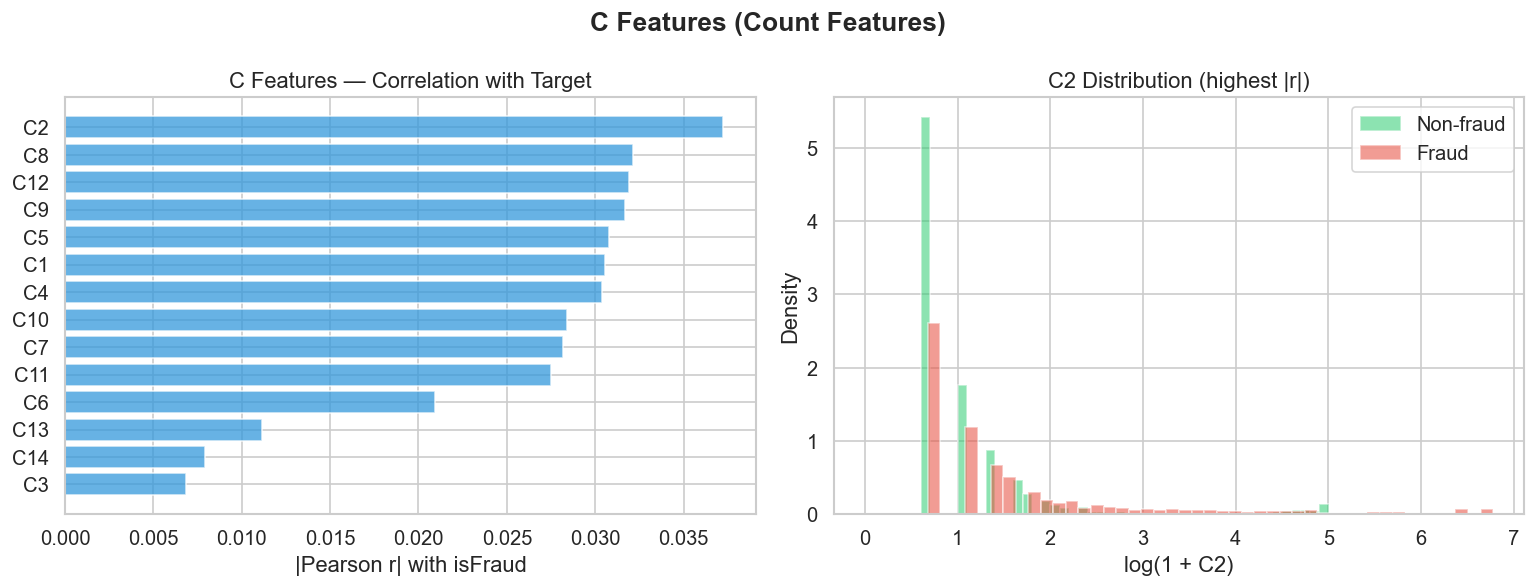

In [ ]:
c_cols = [f'C{i}' for i in range(1, 15) if f'C{i}' in df.columns]

print('C feature summary (fraud vs non-fraud medians):')
medians = df.groupby('isFraud')[c_cols].median()
medians.index = ['Non-fraud', 'Fraud']
print(medians.T.round(1).to_string())

# Correlation with isFraud
c_corr = df[c_cols].corrwith(df['isFraud']).abs().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(c_corr.index, c_corr.values, color=NEUTRAL_COLOR, alpha=0.75)
axes[0].set_xlabel('|Pearson r| with isFraud')
axes[0].set_title('C Features - Correlation with Target')

# Distribution of top C feature
top_c = c_corr.index[-1]
for label, grp_df, color in [('Non-fraud', df[df['isFraud']==0], LEGIT_COLOR),
                               ('Fraud',     df[df['isFraud']==1], FRAUD_COLOR)]:
    axes[1].hist(
        np.log1p(grp_df[top_c].clip(upper=grp_df[top_c].quantile(0.99))),
        bins=50, alpha=0.55, density=True, label=label, color=color
    )
axes[1].set_xlabel(f'log(1 + {top_c})')
axes[1].set_ylabel('Density')
axes[1].set_title(f'{top_c} Distribution (highest |r|)')
axes[1].legend()

plt.suptitle('C Features (Count Features)', fontweight='bold')
plt.tight_layout()
plt.show()

## 8 · D features (time-delta features)

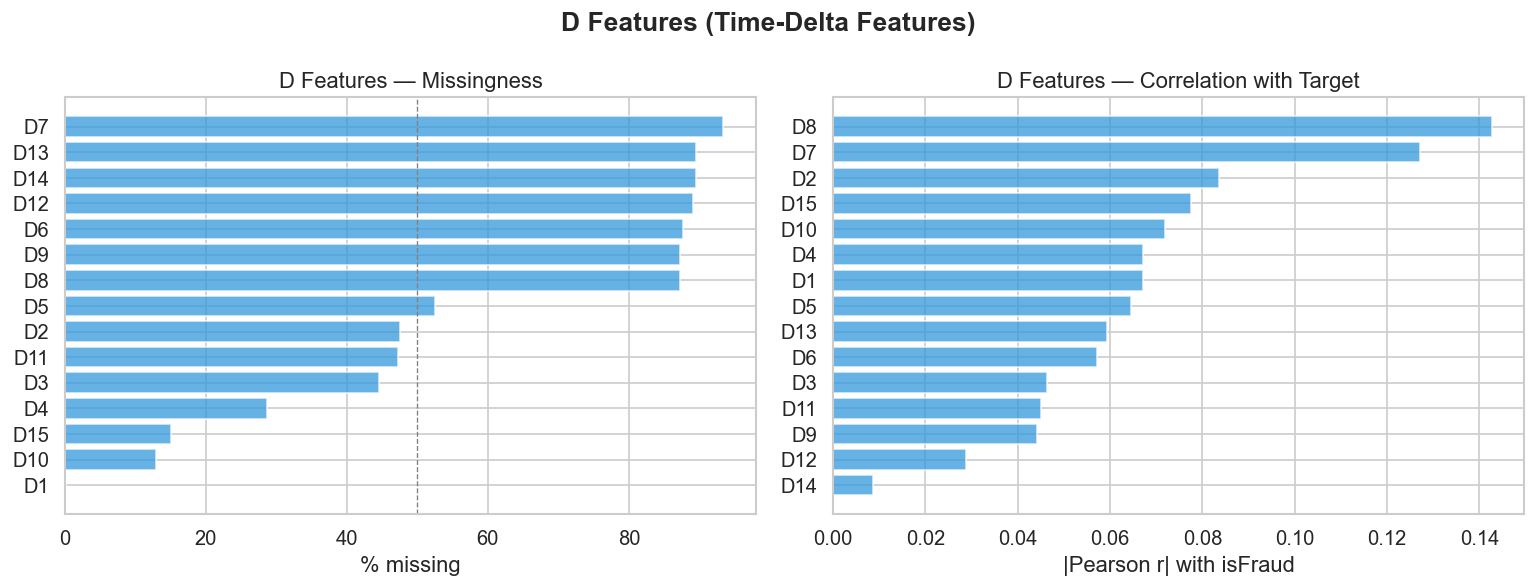

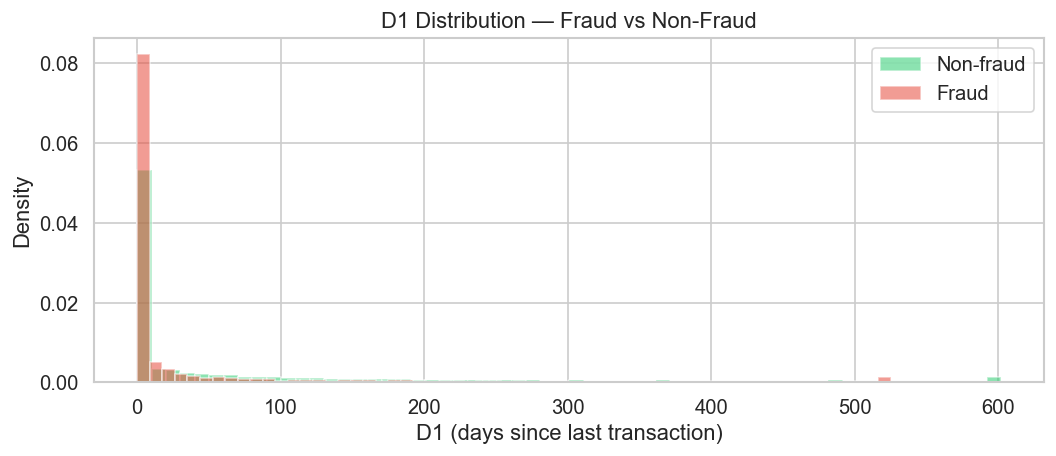

In [ ]:
d_cols = [f'D{i}' for i in range(1, 16) if f'D{i}' in df.columns]

# Missing rate
d_miss = df[d_cols].isnull().mean() * 100

# Correlation with isFraud (on non-null values)
d_corr = df[d_cols].corrwith(df['isFraud']).abs()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(d_miss.sort_values().index, d_miss.sort_values().values,
             color=NEUTRAL_COLOR, alpha=0.75)
axes[0].set_xlabel('% missing')
axes[0].set_title('D Features - Missingness')
axes[0].axvline(50, color='gray', linestyle='--', linewidth=0.8)

axes[1].barh(d_corr.sort_values().index, d_corr.sort_values().values,
             color=NEUTRAL_COLOR, alpha=0.75)
axes[1].set_xlabel('|Pearson r| with isFraud')
axes[1].set_title('D Features - Correlation with Target')

plt.suptitle('D Features (Time-Delta Features)', fontweight='bold')
plt.tight_layout()
plt.show()

# D1 is "days since last transaction" - distributions by class
if 'D1' in df.columns:
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, grp_df, color in [('Non-fraud', df[df['isFraud']==0], LEGIT_COLOR),
                                   ('Fraud',     df[df['isFraud']==1], FRAUD_COLOR)]:
        ax.hist(grp_df['D1'].dropna().clip(upper=grp_df['D1'].quantile(0.99)),
                bins=60, alpha=0.55, density=True, label=label, color=color)
    ax.set_xlabel('D1 (days since last transaction)')
    ax.set_ylabel('Density')
    ax.set_title('D1 Distribution - Fraud vs Non-Fraud')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 9 · M features (match flags)

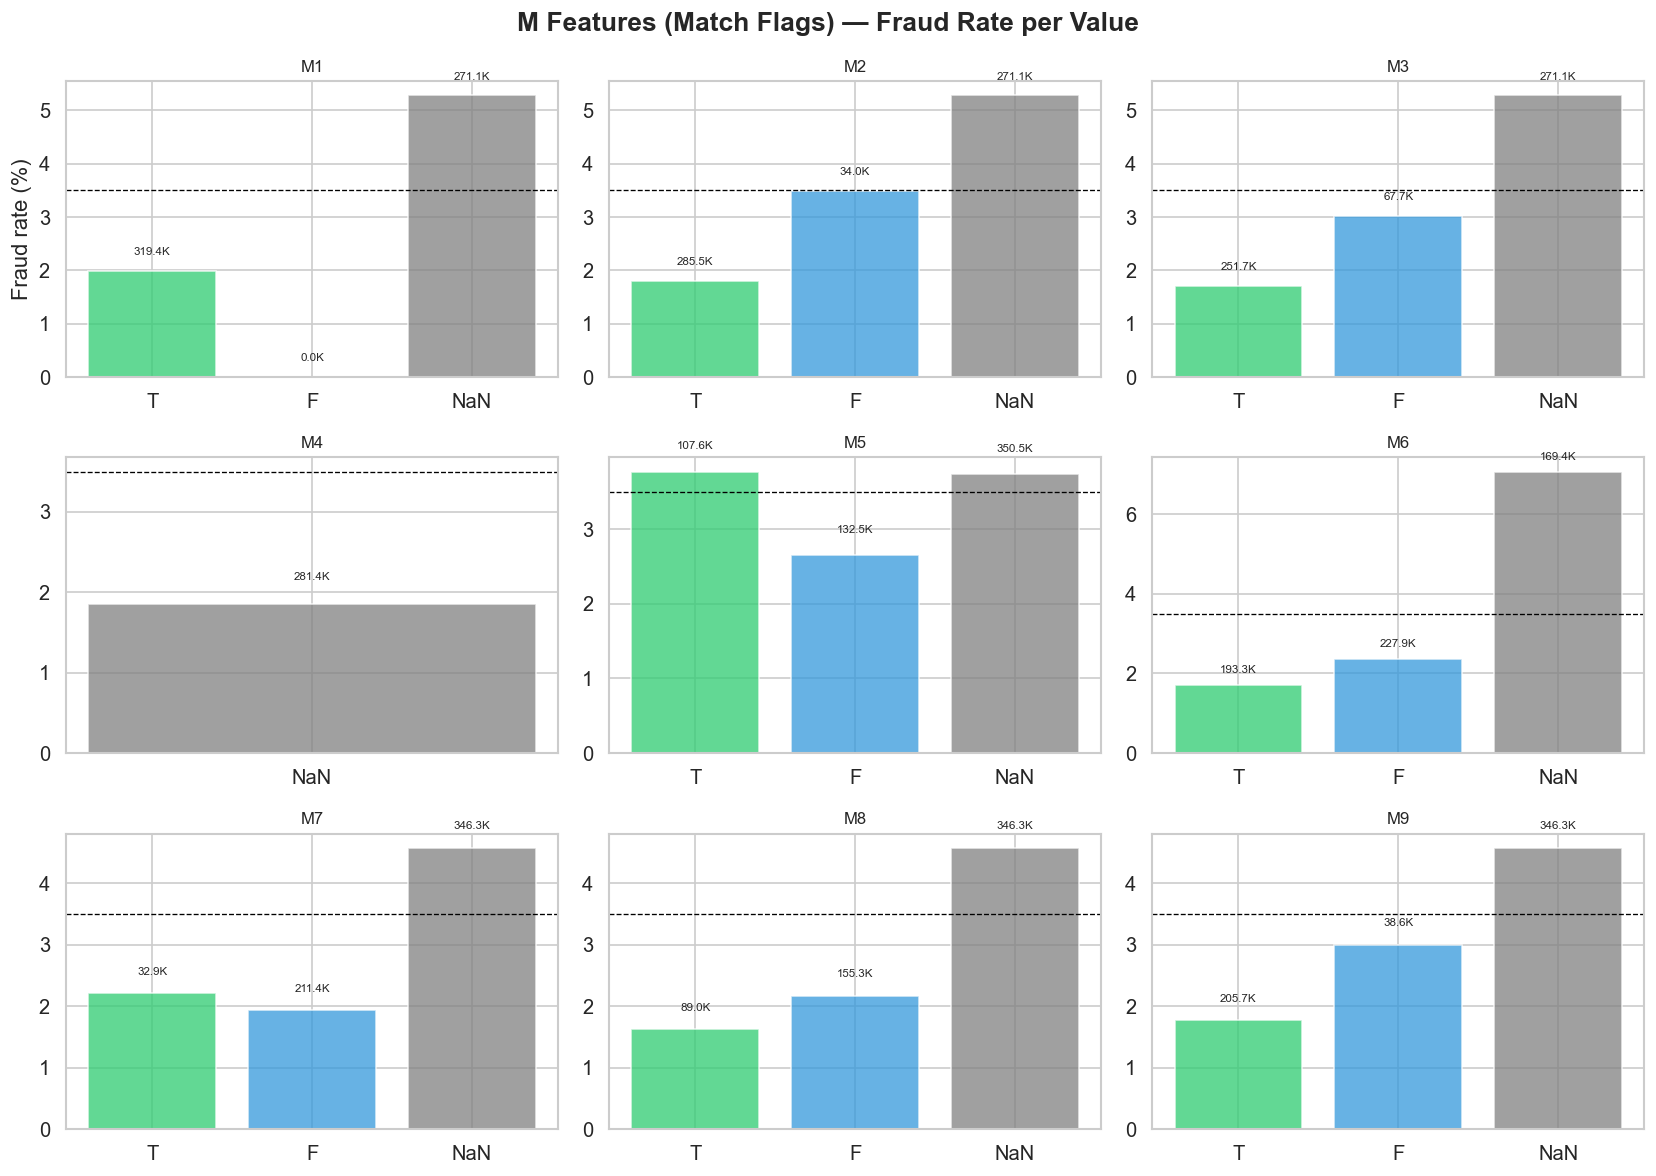

In [ ]:
m_cols = [f'M{i}' for i in range(1, 10) if f'M{i}' in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, m_cols):
    rates = df.groupby(col)['isFraud'].mean() * 100
    counts = df[col].value_counts(dropna=False)

    # Stacked: fraud rate per flag value + NaN
    values = df[col].fillna('NaN')
    for val, color in [('T', LEGIT_COLOR), ('F', NEUTRAL_COLOR), ('NaN', 'gray')]:
        mask = values == val
        if mask.sum() == 0:
            continue
        rate = df.loc[mask, 'isFraud'].mean() * 100
        cnt  = mask.sum()
        ax.bar(val, rate, color=color, alpha=0.75)
        ax.text(val, rate + 0.3, f'{cnt/1000:.1f}K', ha='center', fontsize=7)

    ax.axhline(df['isFraud'].mean() * 100, color='black',
               linestyle='--', linewidth=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Fraud rate (%)' if ax == axes[0] else '')

for ax in axes[len(m_cols):]:
    ax.set_visible(False)

plt.suptitle('M Features (Match Flags) - Fraud Rate per Value', fontweight='bold')
plt.tight_layout()
plt.show()

## 10 · V features (Vesta engineered)

Total V columns: 339


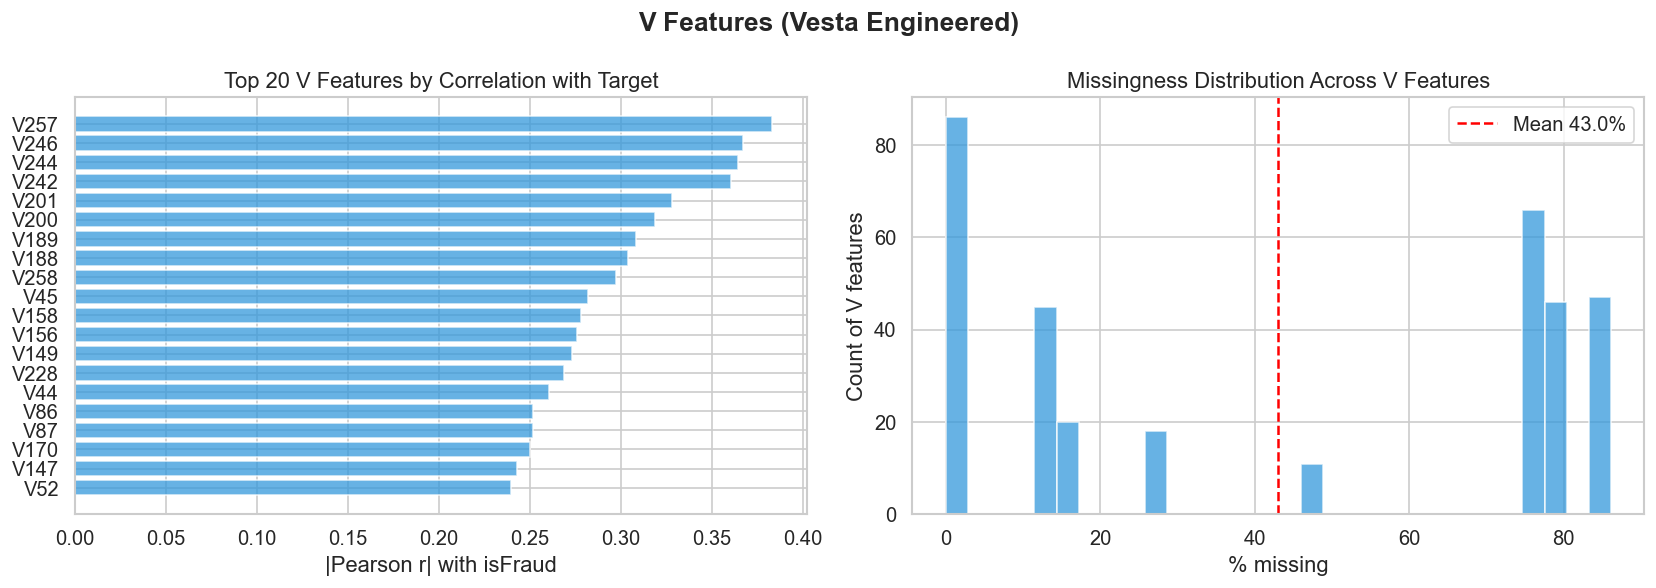


Top 5 V features by |r|:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005

Missing rate p50: 47.3%
Missing rate p95: 86.1%


In [13]:
v_cols = [c for c in df.columns if c.startswith('V') and c[1:].isdigit()]
print(f'Total V columns: {len(v_cols)}')

# Correlation with target
v_corr = df[v_cols].corrwith(df['isFraud']).abs()
top_v  = v_corr.sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_v.index[::-1], top_v.values[::-1], color=NEUTRAL_COLOR, alpha=0.75)
axes[0].set_xlabel('|Pearson r| with isFraud')
axes[0].set_title('Top 20 V Features by Correlation with Target')

# Missing rate distribution across all V features
v_miss = df[v_cols].isnull().mean() * 100
axes[1].hist(v_miss.values, bins=30, color=NEUTRAL_COLOR, alpha=0.75, edgecolor='white')
axes[1].set_xlabel('% missing')
axes[1].set_ylabel('Count of V features')
axes[1].set_title('Missingness Distribution Across V Features')
axes[1].axvline(v_miss.mean(), color='red', linestyle='--',
                label=f'Mean {v_miss.mean():.1f}%')
axes[1].legend()

plt.suptitle('V Features (Vesta Engineered)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTop 5 V features by |r|:')
print(top_v.head().to_string())
print(f'\nMissing rate p50: {v_miss.median():.1f}%')
print(f'Missing rate p95: {v_miss.quantile(0.95):.1f}%')

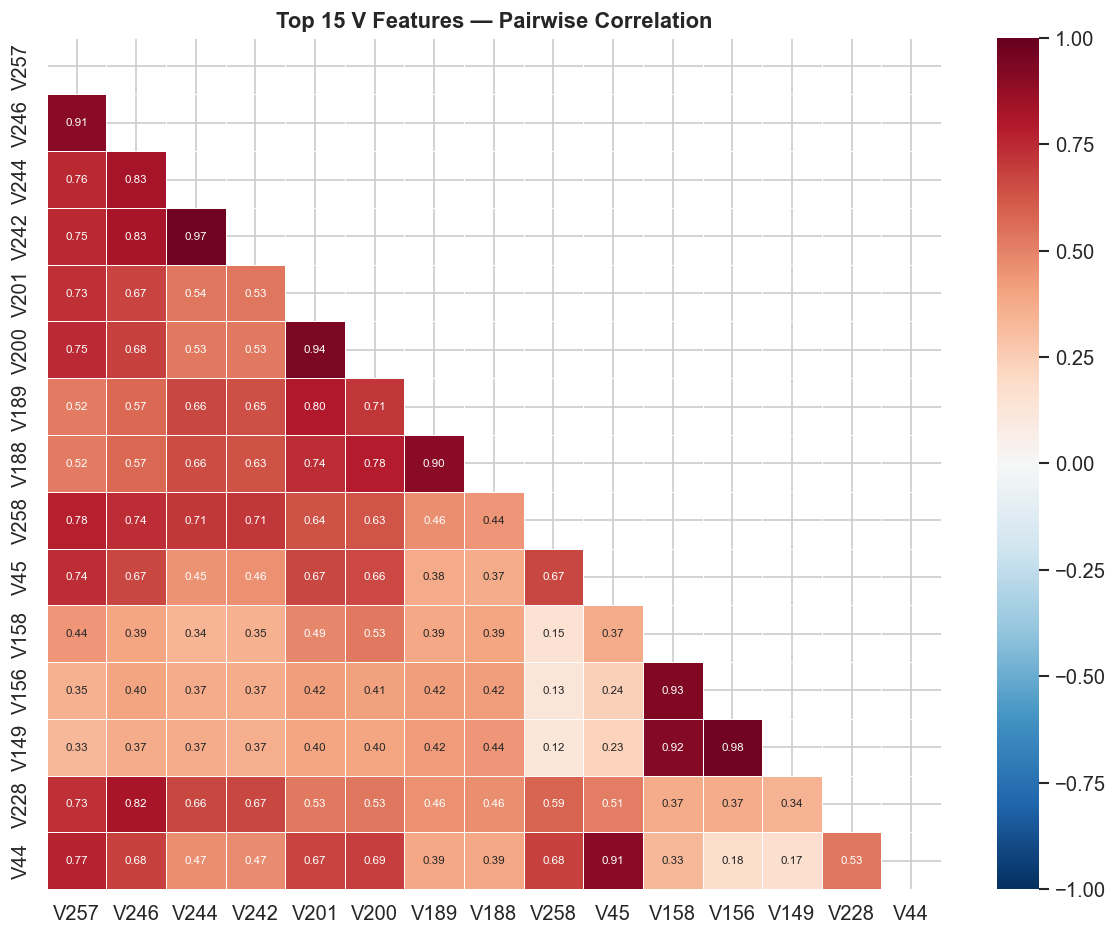


V feature pairs with |r| > 0.85: 15
→ High collinearity expected — tree models handle this naturally.


In [ ]:
# Pairwise correlation between top V features (collinearity check)
top_v_cols = top_v.head(15).index.tolist()
v_corr_matrix = df[top_v_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(v_corr_matrix, dtype=bool))
sns.heatmap(
    v_corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Top 15 V Features - Pairwise Correlation', fontweight='bold')
plt.tight_layout()
plt.show()

high_corr = (v_corr_matrix.abs() > 0.85).sum().sum() // 2
print(f'\nV feature pairs with |r| > 0.85: {high_corr}')
print('→ High collinearity expected - tree models handle this naturally.')

## 11 · Identity features

Identity columns: 38
Rows with any identity data: 144,233

DeviceType fraud rates:
              mean   count
DeviceType                
desktop     0.0652   85165
mobile      0.1017   55645
NaN         0.0210  449730


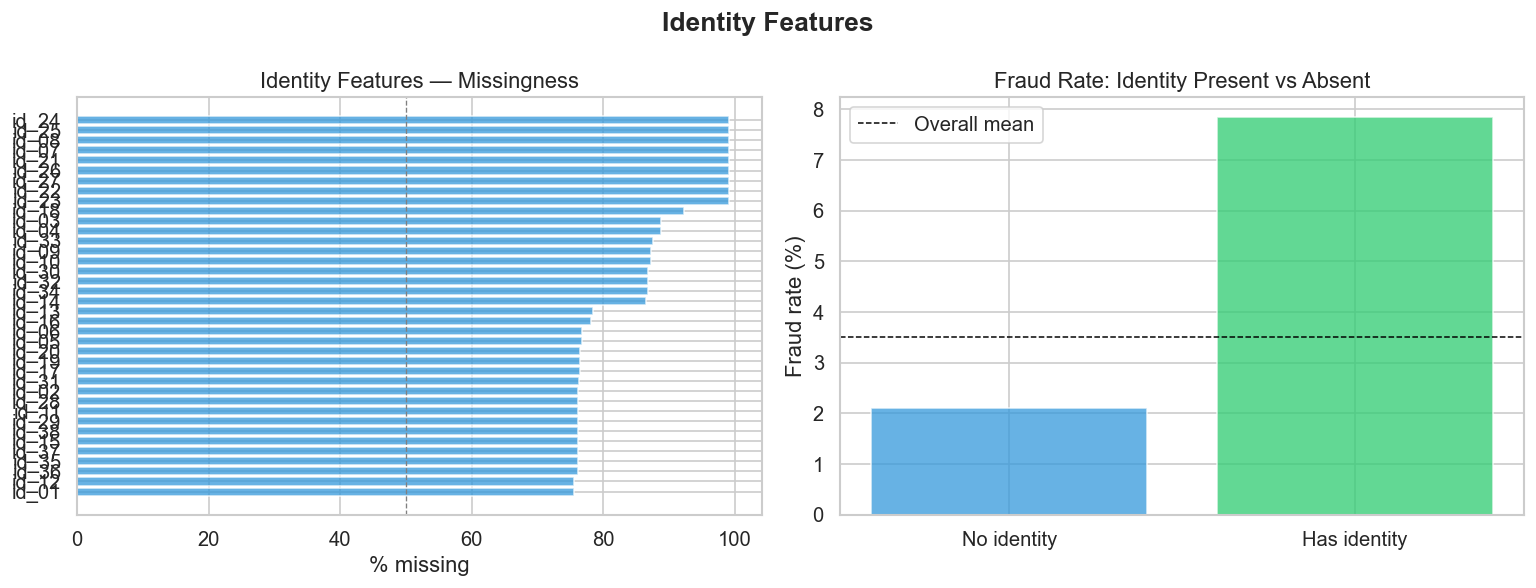

In [ ]:
id_cols = [c for c in df.columns if c.startswith('id_')]
print(f'Identity columns: {len(id_cols)}')
print(f'Rows with any identity data: {df[id_cols].notna().any(axis=1).sum():,}')

# DeviceType fraud rate
if 'DeviceType' in df.columns:
    dt_rate = df.groupby('DeviceType', dropna=False)['isFraud'].agg(['mean', 'count'])
    print('\nDeviceType fraud rates:')
    print(dt_rate.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Missing rate for identity features
id_miss = df[id_cols].isnull().mean() * 100
axes[0].barh(id_miss.sort_values().index, id_miss.sort_values().values,
             color=NEUTRAL_COLOR, alpha=0.75)
axes[0].set_xlabel('% missing')
axes[0].set_title('Identity Features - Missingness')
axes[0].axvline(50, color='gray', linestyle='--', linewidth=0.8)

# Identity presence vs fraud rate
df['_has_identity'] = df[id_cols].notna().any(axis=1).astype(int)
has_id_rate = df.groupby('_has_identity')['isFraud'].mean() * 100
axes[1].bar(['No identity', 'Has identity'], has_id_rate.values,
            color=[NEUTRAL_COLOR, LEGIT_COLOR], alpha=0.75)
axes[1].axhline(df['isFraud'].mean() * 100, color='black',
                linestyle='--', linewidth=0.9, label='Overall mean')
axes[1].set_ylabel('Fraud rate (%)')
axes[1].set_title('Fraud Rate: Identity Present vs Absent')
axes[1].legend()

df.drop(columns=['_has_identity'], inplace=True)

plt.suptitle('Identity Features', fontweight='bold')
plt.tight_layout()
plt.show()

## 12 · Correlation heatmap (core numeric features)

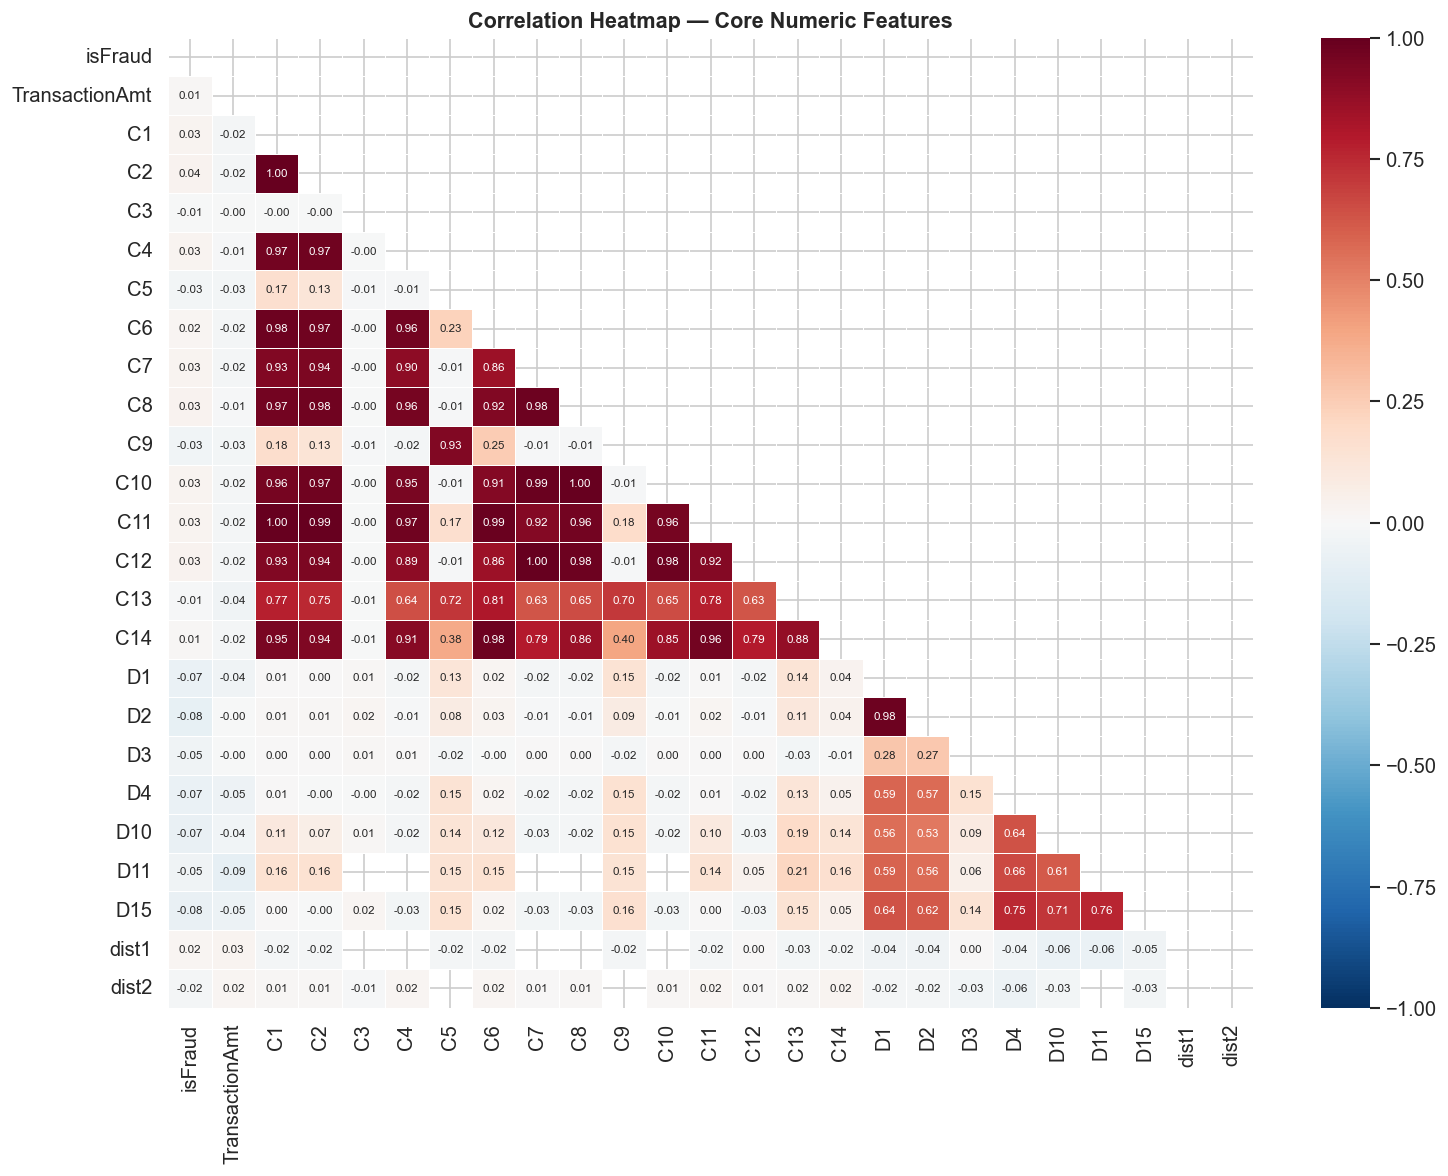

Top 10 core numeric features by |r| with isFraud:
D2     0.0836
D15    0.0775
D10    0.0720
D4     0.0672
D1     0.0672
D3     0.0463
D11    0.0451
C2     0.0372
C8     0.0321
C12    0.0319


In [ ]:
core_numeric = (
    ['isFraud', 'TransactionAmt']
    + [f'C{i}' for i in range(1, 15) if f'C{i}' in df.columns]
    + [f'D{i}' for i in [1, 2, 3, 4, 10, 11, 15] if f'D{i}' in df.columns]
    + ['dist1', 'dist2']
)
core_numeric = [c for c in core_numeric if c in df.columns]

corr_mat = df[core_numeric].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Correlation Heatmap - Core Numeric Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlators with isFraud
target_corr = corr_mat['isFraud'].drop('isFraud').abs().sort_values(ascending=False)
print('Top 10 core numeric features by |r| with isFraud:')
print(target_corr.head(10).round(4).to_string())

## 13 · Key findings

In [17]:
fraud_rate_pct = df['isFraud'].mean() * 100
n_total        = len(df)
n_fraud        = df['isFraud'].sum()
n_cols         = len(df.columns)
pct_gt50_miss  = (df.isnull().mean() > 0.5).mean() * 100
n_v_cols       = len([c for c in df.columns if c.startswith('V') and c[1:].isdigit()])

print('=' * 60)
print('KEY FINDINGS - FraudLens EDA')
print('=' * 60)
print(f'''
Dataset
  Rows          : {n_total:,}
  Columns       : {n_cols}
  Fraud cases   : {n_fraud:,}  ({fraud_rate_pct:.2f}%)
  Imbalance     : {(1-fraud_rate_pct/100)/(fraud_rate_pct/100):.0f}:1 (non-fraud:fraud)

Missing values
  Cols >50% NaN : {pct_gt50_miss:.1f}% of all columns
  V features    : {n_v_cols} columns, highly variable missingness
  D features    : heavy missingness, especially D7-D9
  M features    : T/F/NaN tri-state → encode as 1/0/-1

Signal quality
  TransactionAmt: fraud distribution right-shifted (higher median)
  Email domain  : mismatched domains have elevated fraud rate
  Hour of day   : fraud rate spikes in low-volume hours (overnight)
  C features    : C1, C6, C13, C14 show highest |r| with target
  V features    : strong signal in V95–V137 range (card-related)

Feature engineering plan (features.py)
  ✓ Temporal: hour, day_of_week from TransactionDT
  ✓ Email: domain match flag, anonymous flag, root domain
  ✓ Card aggregates: amt mean/std/count by card1 and uid=card1+addr1
  ✓ Amount z-score relative to card history
  ✓ Target encoding (OOF, smoothed): card1/2/3/5, addr1/2, email domains
  ✓ Label encoding: ProductCD, card4/6, M1-M9, DeviceType
  ✓ Imputation: median for numeric, -1 sentinel for M-flags

Primary metric: AUC-PR (appropriate for 3.5% positive rate)
''')

KEY FINDINGS - FraudLens EDA

Dataset
  Rows          : 590,540
  Columns       : 434
  Fraud cases   : 20,663  (3.50%)
  Imbalance     : 28:1 (non-fraud:fraud)

Missing values
  Cols >50% NaN : 49.3% of all columns
  V features    : 339 columns, highly variable missingness
  D features    : heavy missingness, especially D7-D9
  M features    : T/F/NaN tri-state → encode as 1/0/-1

Signal quality
  TransactionAmt: fraud distribution right-shifted (higher median)
  Email domain  : mismatched domains have elevated fraud rate
  Hour of day   : fraud rate spikes in low-volume hours (overnight)
  C features    : C1, C6, C13, C14 show highest |r| with target
  V features    : strong signal in V95–V137 range (card-related)

Feature engineering plan (features.py)
  ✓ Temporal: hour, day_of_week from TransactionDT
  ✓ Email: domain match flag, anonymous flag, root domain
  ✓ Card aggregates: amt mean/std/count by card1 and uid=card1+addr1
  ✓ Amount z-score relative to card history
  ✓ Target e